# 미니프로젝트 6: Day 1~6 통합 복습 (Vibe Coding)

#### <목표>
Day1 ~ 6에서 배운 머신러닝 프로세스 전체를 새로운 데이터셋(신용카드 고객 채무불이행)에 자유롭게 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>
- Default of Credit Card Clients (대만 신용카드 고객 채무불이행 데이터)
- 30,000명의 신용카드 고객 정보로 다음 달 채무불이행 여부를 예측

| 변수명 | 설명 |
|:---:|:---|
| LIMIT_BAL | 신용한도 |
| SEX, EDUCATION, MARRIAGE, AGE | 고객 인적사항 |
| PAY_0, PAY_2~PAY_6 | 최근 6개월 월별 연체 상태 (-1: 정상납부, 1 이상: 연체 개월 수) |
| BILL_AMT1~6 | 최근 6개월 청구액 |
| PAY_AMT1~6 | 최근 6개월 납부액 |
| default payment next month | 다음 달 채무불이행 여부 (1: 불이행, 0: 정상) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `default payment next month` | 고객 정보로 다음 달 채무불이행 여부 예측 |

1. 각 섹션의 **과제**를 읽고, Day1~6 중 어떤 내용을 적용해야 할지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day6_miniproject.csv` 파일을 사용하기
- 타겟 변수: `default payment next month` (0: 정상, 1: 채무불이행)

**[과제]** 써니는 신용카드 고객 채무불이행 데이터를 분석하게 되었습니다. 분석에 필요한 라이브러리와 데이터를 불러오는 코드를 AI와 상의해서 작성하세요.

In [1]:
# 추가 패키지 (최초 1회만 설치)
# !pip install imbalanced-learn xgboost lightgbm catboost mrmr-selection boruta shap stucco

import os
import warnings
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
import seaborn as sns

warnings.filterwarnings("ignore")

# ===== 한글 폰트 설정 =====
FONT_CANDIDATES = [
    "/System/Library/Fonts/AppleSDGothicNeo.ttc",
    "/System/Library/Fonts/Supplemental/AppleGothic.ttf",
    "C:/Windows/Fonts/malgun.ttf",
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
]
FONT_PATH = next((p for p in FONT_CANDIDATES if os.path.exists(p)), None)
if FONT_PATH:
    fm.fontManager.addfont(FONT_PATH)
    KOREAN_FONT = fm.FontProperties(fname=FONT_PATH)
    rcParams["font.family"] = KOREAN_FONT.get_name()
else:
    KOREAN_FONT = None
rcParams["axes.unicode_minus"] = False

# 데이터 로드
df = pd.read_csv("dataset/day6_miniproject.csv")
TARGET = "default payment next month"

print("데이터 크기:", df.shape)
print("\n컬럼 목록:")
print(df.columns.tolist())
print("\n타겟 분포:")
print(df[TARGET].value_counts())
df.head()

데이터 크기: (30000, 24)

컬럼 목록:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

타겟 분포:
default payment next month
0    23364
1     6636
Name: count, dtype: int64


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 1) 데이터 탐색 (EDA)

1. Value 기반 탐색 (구조적/통계적)
2. Graph 기반 탐색 (단일 변수/변수 간/여러 변수 간)

**[과제]** 써니는 모델링을 수행하기 전에 필요한 전처리 과정을 파악하기 위해 데이터 탐색(EDA)이 필요하다고 생각했습니다.

AI와 상의하여 데이터의 구조적 정보(변수 타입, 결측치 유무 등)와 통계적 정보(변수별 고유값 개수, 기초통계량 등)를 확인하는 코드를 작성하고, 결과를 분석해 보세요.


In [2]:
# ===== 1) 구조적 정보 =====
print("=== 데이터 타입 ===")
print(df.dtypes)

print("\n=== 결측치 개수 ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "결측치 없음")

print("\n=== 중복 행 ===")
print(f"중복 행 수: {df.duplicated().sum()}")

print("\n=== 변수별 고유값 개수 ===")
nunique = df.nunique().sort_values()
display(nunique.to_frame("nunique"))

print("\n=== 기초통계량 (수치형) ===")
display(df.describe().T.round(2))

# 범주형 변수 값 분포 확인
cat_cols_raw = ["SEX", "EDUCATION", "MARRIAGE"]
print("\n=== 범주형 변수 분포 ===")
for col in cat_cols_raw:
    print(f"\n[{col}]")
    print(df[col].value_counts().sort_index())

print("\n=== 타겟 변수 불균형 비율 ===")
ratio = df[TARGET].value_counts(normalize=True)
print(ratio.round(4))
print(f"불이행(1) 비율: {ratio.get(1, 0):.2%}")

=== 데이터 타입 ===
LIMIT_BAL                     int64
SEX                           int64
EDUCATION                     int64
MARRIAGE                      int64
AGE                           int64
PAY_0                         int64
PAY_2                         int64
PAY_3                         int64
PAY_4                         int64
PAY_5                         int64
PAY_6                         int64
BILL_AMT1                     int64
BILL_AMT2                     int64
BILL_AMT3                     int64
BILL_AMT4                     int64
BILL_AMT5                     int64
BILL_AMT6                     int64
PAY_AMT1                      int64
PAY_AMT2                      int64
PAY_AMT3                      int64
PAY_AMT4                      int64
PAY_AMT5                      int64
PAY_AMT6                      int64
default payment next month    int64
dtype: object

=== 결측치 개수 ===
결측치 없음

=== 중복 행 ===
중복 행 수: 35

=== 변수별 고유값 개수 ===


,nunique
default payment next month,2
SEX,2
MARRIAGE,4
EDUCATION,7
PAY_5,10
PAY_6,10
PAY_0,11
PAY_2,11
PAY_3,11
PAY_4,11



=== 기초통계량 (수치형) ===


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.0,167484.32,129747.66,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.60,0.49,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.85,0.79,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.55,0.52,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.49,9.22,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.02,1.12,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.13,1.20,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.17,1.20,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.22,1.17,-2.0,-1.00,0.0,0.00,8.0
PAY_5,30000.0,-0.27,1.13,-2.0,-1.00,0.0,0.00,8.0



=== 범주형 변수 분포 ===

[SEX]
SEX
1    11888
2    18112
Name: count, dtype: int64

[EDUCATION]
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

[MARRIAGE]
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

=== 타겟 변수 불균형 비율 ===
default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64
불이행(1) 비율: 22.12%


**[과제]** 써니는 데이터의 분포에 따라 필요한 전처리와 분석 방법이 달라질 수 있다고 생각했습니다.

AI와 상의하여 범주형 변수와 연속형 변수의 분포를 시각화하고 어떤 전처리와 분석이 필요한지 탐구해 보세요.

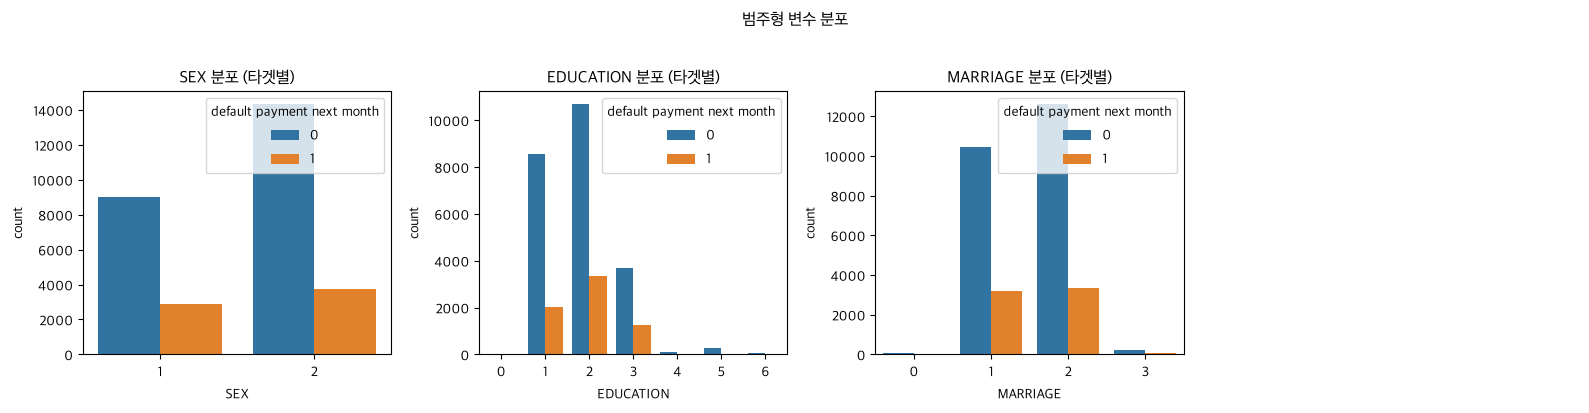

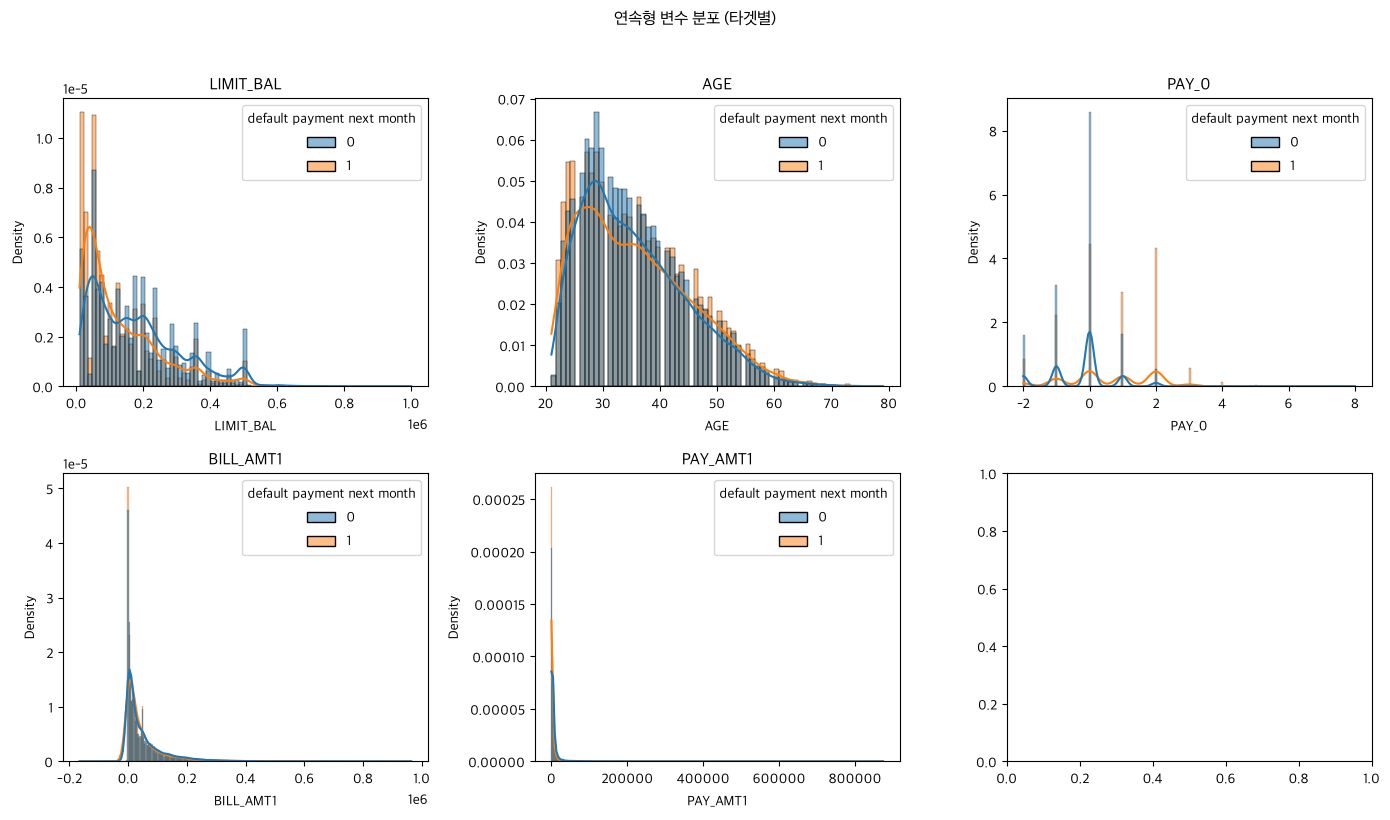

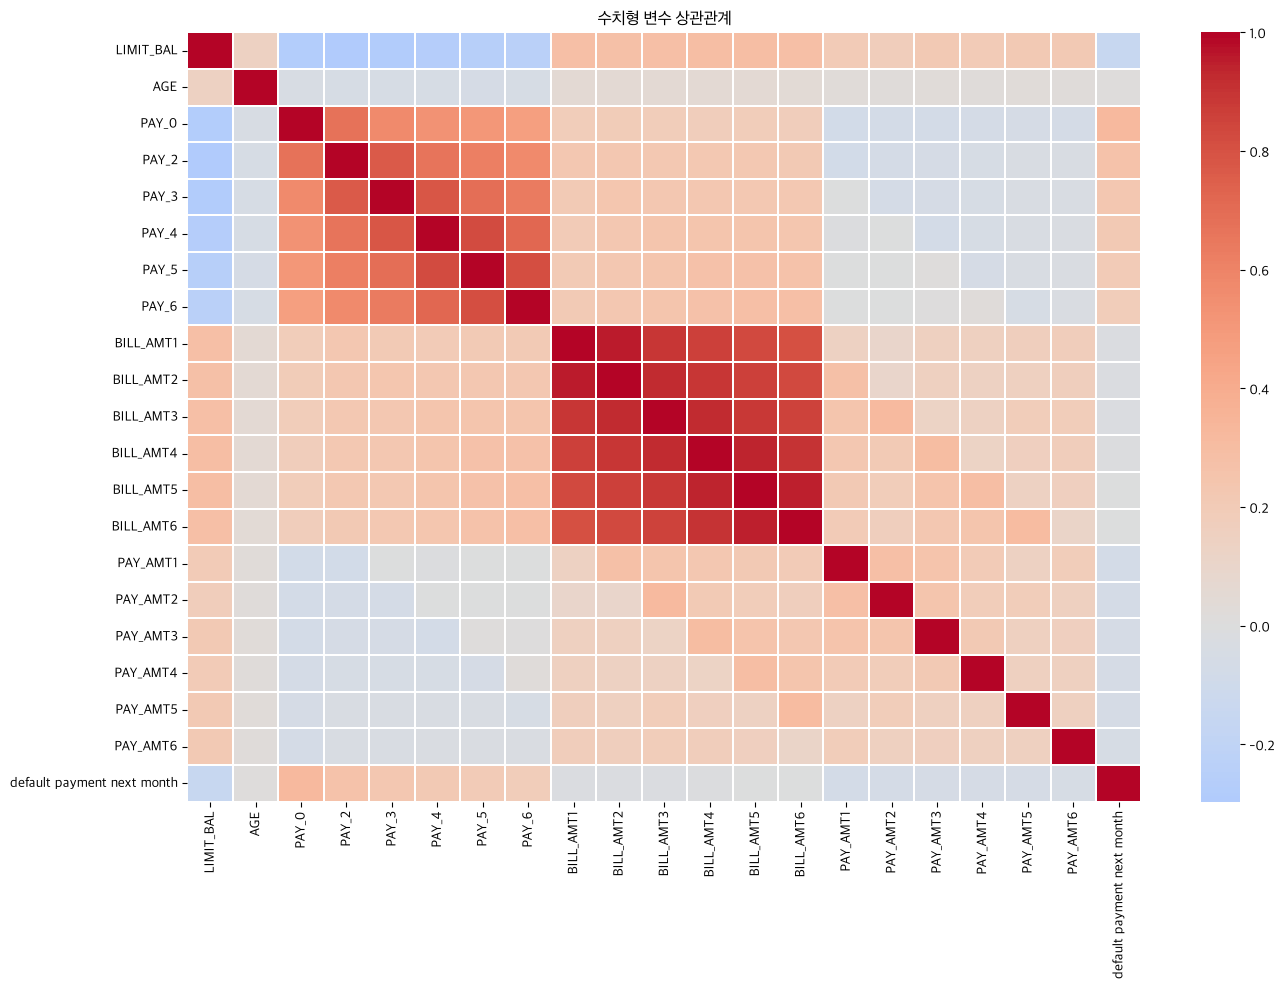

=== EDA 기반 전처리/분석 시사점 ===
1. 결측치는 없으나 EDUCATION(0,5,6), MARRIAGE(0) 등 비정상 코드 → 범주 정리 필요
2. BILL_AMT*, PAY_AMT* 변수 간 높은 상관 → 다중공선성 점검(VIF) 고려
3. LIMIT_BAL, BILL_AMT 등 금액 변수는 우편향 → 스케일링 필요
4. 타겟 불균형(정상 78% vs 불이행 22%) → class_weight 또는 리샘플링 고려
5. PAY_* 연체 상태는 범주 의미가 강함 → 트리/앙상블 모델에 유리


In [3]:
# 범주형/연속형 변수 구분
cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
num_cols = [c for c in df.columns if c not in cat_cols + [TARGET]]

# --- 범주형 변수 분포 ---
fig, axes = plt.subplots(1, len(cat_cols) + 1, figsize=(16, 4))
for ax, col in zip(axes[:3], cat_cols):
    sns.countplot(data=df, x=col, hue=TARGET, ax=ax)
    ax.set_title(f"{col} 분포 (타겟별)")
axes[-1].axis("off")
plt.suptitle("범주형 변수 분포", y=1.02)
plt.tight_layout()
plt.show()

# --- 연속형 변수 분포 (히스토그램) ---
plot_nums = ["LIMIT_BAL", "AGE", "PAY_0", "BILL_AMT1", "PAY_AMT1"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), plot_nums):
    sns.histplot(data=df, x=col, hue=TARGET, kde=True, ax=ax, stat="density", common_norm=False)
    ax.set_title(col)
plt.suptitle("연속형 변수 분포 (타겟별)", y=1.02)
plt.tight_layout()
plt.show()

# --- 상관관계 히트맵 ---
plt.figure(figsize=(14, 10))
corr = df[num_cols + [TARGET]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("수치형 변수 상관관계")
plt.tight_layout()
plt.show()

print("=== EDA 기반 전처리/분석 시사점 ===")
print("1. 결측치는 없으나 EDUCATION(0,5,6), MARRIAGE(0) 등 비정상 코드 → 범주 정리 필요")
print("2. BILL_AMT*, PAY_AMT* 변수 간 높은 상관 → 다중공선성 점검(VIF) 고려")
print("3. LIMIT_BAL, BILL_AMT 등 금액 변수는 우편향 → 스케일링 필요")
print("4. 타겟 불균형(정상 78% vs 불이행 22%) → class_weight 또는 리샘플링 고려")
print("5. PAY_* 연체 상태는 범주 의미가 강함 → 트리/앙상블 모델에 유리")

---

## 2) 데이터 전처리

1. 불필요한 변수 제거
2. 다중공선성 해결
3. 결측치 처리
4. 이상치 처리
5. 클래스 불균형 문제 해결
6. 스케일링/인코딩
7. 변수 내 데이터 값을 적절한 값으로 변경 (ex. "Yes" -> 1)

**[과제]** 써니는 EDA 결과를 바탕으로 모델링에 필요한 전처리 과정을 계획하고자 합니다.

AI와 상의하여 필요한 전처리 항목을 나열한 뒤, 학습 데이터와 테스트 데이터 분할 시점을 고려하여 분할 전에 수행해야 하는 전처리와 분할 후에 수행해야 하는 전처리를 구분해 보세요. 

이후 올바른 순서에 따라 전처리를 진행해 보세요.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ===== 전처리 계획 =====
preprocess_plan = pd.DataFrame([
    ["범주 코드 정리", "EDUCATION/MARRIAGE 비정상 코드 통합", "분할 전", "전체 데이터"],
    ["다중공선성 점검", "VIF로 고상관 변수 확인", "분할 전", "전체 데이터"],
    ["결측치 처리", "현재 결측 없음 → 스킵", "분할 전", "-"],
    ["이상치 처리", "극단 금액값은 정보일 수 있어 보수적 유지", "분할 전", "전체 데이터"],
    ["Train/Test 분할", "stratify로 클래스 비율 유지", "분할 시점", "전체 데이터"],
    ["스케일링/인코딩", "수치형 StandardScaler, 범주형 OneHot", "분할 후", "학습 데이터 fit → 테스트 transform"],
    ["클래스 불균형", "SMOTE 등 리샘플링", "분할 후", "학습 데이터만"],
], columns=["항목", "방법", "시점", "적용 범위"])
print("=== 전처리 계획 ===")
display(preprocess_plan)

# ===== 1) 분할 전 전처리 =====
data = df.copy()

# EDUCATION: 1=대학원, 2=대학, 3=고등학교, 4=기타 / 0,5,6은 기타(4)로 통합
# MARRIAGE: 1=기혼, 2=미혼, 3=기타 / 0은 기타(3)로 통합
edu_map = {0: 4, 5: 4, 6: 4, 1: 1, 2: 2, 3: 3, 4: 4}
mar_map = {0: 3, 1: 1, 2: 2, 3: 3}
data["EDUCATION"] = data["EDUCATION"].map(edu_map)
data["MARRIAGE"] = data["MARRIAGE"].map(mar_map)

cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
num_cols = [c for c in data.columns if c not in cat_cols + [TARGET]]

# VIF 점검 (다중공선성 참고용)
X_vif = data[num_cols].copy()
vif_df = pd.DataFrame({
    "feature": num_cols,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(len(num_cols))]
}).sort_values("VIF", ascending=False)
print("\n=== VIF 상위 10개 (참고) ===")
display(vif_df.head(10))
print("→ BILL_AMT/PAY_AMT 시계열 변수 간 상관이 높아 VIF가 큼. 트리 모델은 영향 적음.")

# ===== 2) Train/Test 분할 =====
y = data[TARGET]
X = data.drop(columns=[TARGET])
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===== 3) 분할 후 전처리 (학습 데이터 기준 fit) =====
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ]
)
X_train_proc = preprocessor.fit_transform(X_train_raw)
X_test_proc = preprocessor.transform(X_test_raw)

feature_names = num_cols + list(
    preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols)
)
X_train = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train_raw.index)
X_test = pd.DataFrame(X_test_proc, columns=feature_names, index=X_test_raw.index)

print(f"\n전처리 후 학습 데이터: {X_train.shape} | 테스트 데이터: {X_test.shape}")
print("\n[Train] 클래스 분포:")
print(y_train.value_counts())
X_train.head()

=== 전처리 계획 ===


,항목,방법,시점,적용 범위
0,범주 코드 정리,EDUCATION/MARRIAGE 비정상 코드 통합,분할 전,전체 데이터
1,다중공선성 점검,VIF로 고상관 변수 확인,분할 전,전체 데이터
2,결측치 처리,현재 결측 없음 → 스킵,분할 전,-
3,이상치 처리,극단 금액값은 정보일 수 있어 보수적 유지,분할 전,전체 데이터
4,Train/Test 분할,stratify로 클래스 비율 유지,분할 시점,전체 데이터
5,스케일링/인코딩,"수치형 StandardScaler, 범주형 OneHot",분할 후,학습 데이터 fit → 테스트 transform
6,클래스 불균형,SMOTE 등 리샘플링,분할 후,학습 데이터만



=== VIF 상위 10개 (참고) ===


,feature,VIF
9,BILL_AMT2,38.209430
12,BILL_AMT5,35.977089
10,BILL_AMT3,31.776657
11,BILL_AMT4,29.546444
13,BILL_AMT6,21.424239
8,BILL_AMT1,20.798397
6,PAY_5,4.984963
5,PAY_4,4.439449
0,LIMIT_BAL,3.842259
4,PAY_3,3.725904


→ BILL_AMT/PAY_AMT 시계열 변수 간 상관이 높아 VIF가 큼. 트리 모델은 영향 적음.

전처리 후 학습 데이터: (24000, 26) | 테스트 데이터: (6000, 26)

[Train] 클래스 분포:
default payment next month
0    18691
1     5309
Name: count, dtype: int64


,LIMIT_BAL,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
22788,-0.056866,-0.264558,1.793311,1.780193,2.652046,1.911811,0.240260,0.256087,1.505547,1.745089,...,-0.297820,0.086961,0.500397,0.048745,1.0,1.0,0.0,0.0,1.0,0.0
29006,-0.134081,-0.155804,0.902944,-0.722324,-0.697642,-1.530826,-1.537252,-1.489963,-0.695165,-0.691138,...,-0.297820,-0.318075,-0.316978,-0.292992,1.0,0.0,0.0,0.0,1.0,0.0
16950,-1.215090,1.584260,0.902944,1.780193,0.139780,0.190493,0.240260,0.256087,-0.556800,-0.576836,...,-0.233069,-0.298554,-0.296710,-0.236970,0.0,1.0,0.0,0.0,0.0,0.0
22280,0.406423,-0.699574,0.012576,0.111849,0.139780,0.190493,0.240260,0.256087,2.119190,2.287237,...,0.152526,0.000642,0.008643,0.043143,1.0,0.0,0.0,0.0,1.0,0.0
11346,1.101358,-0.373312,0.902944,-1.556496,-0.697642,0.190493,0.240260,-1.489963,-0.695165,-0.691886,...,-0.297820,-0.318075,-0.316978,-0.225765,1.0,0.0,0.0,0.0,1.0,0.0


---

## 3) 모델링 및 모델 고도화

1. 단일 모델 (Logistic Regression, Decision Tree)
2. 앙상블 모델 (Random Forest, GBM, XGBoost, LightGBM, CatBoost)

**[과제]** 써니는 본 데이터에 가장 적합한 분류 모델이 무엇인지 알아보고자 합니다.

AI와 상의하여 다양한 분류 모델을 선정하고 학습시키는 코드를 작성한 뒤, Accuracy, Precision, Recall, F1-score, AUC-ROC 등의 분류 평가 지표를 활용하여 모델별 성능을 비교해 보세요.

=== 분류 모델 성능 비교 ===


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,CatBoost,0.7695,0.4834,0.6157,0.5416,0.7789
1,XGBoost,0.7662,0.4771,0.5968,0.5303,0.7749
2,LightGBM,0.7567,0.4622,0.6127,0.5269,0.7763
3,Random Forest,0.8028,0.5621,0.4913,0.5243,0.7619
4,Decision Tree,0.7177,0.4117,0.6451,0.5026,0.7439
5,GBM,0.8175,0.6580,0.3640,0.4687,0.7782
6,Logistic Regression,0.6787,0.3679,0.6307,0.4647,0.7103



F1-score 기준 최고 모델: CatBoost


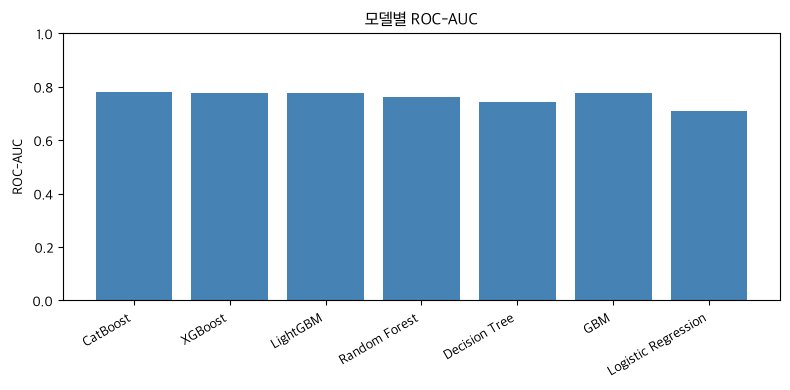

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)

# 선택적 앙상블 패키지
try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None
try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None


def evaluate_classifier(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_te, pred),
        "Precision": precision_score(y_te, pred, zero_division=0),
        "Recall": recall_score(y_te, pred, zero_division=0),
        "F1-score": f1_score(y_te, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_te, proba) if proba is not None else np.nan,
    }


scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1),
    "GBM": GradientBoostingClassifier(n_estimators=200, random_state=42),
}
if XGBClassifier is not None:
    models["XGBoost"] = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=42, verbosity=0,
    )
if LGBMClassifier is not None:
    models["LightGBM"] = LGBMClassifier(
        n_estimators=200, learning_rate=0.05, is_unbalance=True,
        random_state=42, verbose=-1,
    )
if CatBoostClassifier is not None:
    models["CatBoost"] = CatBoostClassifier(
        iterations=200, learning_rate=0.05, depth=6,
        auto_class_weights="Balanced", random_state=42, verbose=0,
    )

results = []
fitted_models = {}
for name, model in models.items():
    row = evaluate_classifier(name, model, X_train, y_train, X_test, y_test)
    results.append(row)
    fitted_models[name] = model

model_compare = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
print("=== 분류 모델 성능 비교 ===")
display(model_compare.round(4))

best_model_name = model_compare.iloc[0]["Model"]
best_model = fitted_models[best_model_name]
print(f"\nF1-score 기준 최고 모델: {best_model_name}")

# ROC-AUC 비교 시각화
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(model_compare["Model"], model_compare["ROC-AUC"], color="steelblue")
ax.set_ylim(0, 1)
ax.set_title("모델별 ROC-AUC")
ax.set_ylabel("ROC-AUC")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**[과제]** 써니는 모델의 성능을 더욱 향상시키고자 합니다.

AI와 상의하여 Grid Search 또는 Random Search를 활용한 하이퍼파라미터 튜닝 코드를 작성하고, 튜닝 전후의 모델 성능을 비교해 보세요.

In [6]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# 튜닝 대상: 앞 단계에서 F1이 가장 높았던 모델
print(f"튜닝 대상 모델: {best_model_name}")

# 모델별 탐색 공간 정의
search_spaces = {
    "Random Forest": (
        RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1),
        {
            "n_estimators": [200, 400],
            "max_depth": [8, 12, None],
            "min_samples_leaf": [1, 3, 5],
            "max_features": ["sqrt", 0.5],
        },
    ),
    "GBM": (
        GradientBoostingClassifier(random_state=42),
        {
            "n_estimators": [100, 200, 300],
            "learning_rate": [0.03, 0.05, 0.1],
            "max_depth": [3, 5],
            "subsample": [0.8, 1.0],
        },
    ),
    "Logistic Regression": (
        LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42),
        {"C": [0.01, 0.1, 1, 10]},
    ),
    "Decision Tree": (
        DecisionTreeClassifier(class_weight="balanced", random_state=42),
        {"max_depth": [5, 8, 12, None], "min_samples_leaf": [1, 3, 10]},
    ),
}
if XGBClassifier is not None:
    search_spaces["XGBoost"] = (
        XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42, verbosity=0),
        {
            "n_estimators": [200, 400],
            "max_depth": [4, 6, 8],
            "learning_rate": [0.03, 0.05, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0],
        },
    )
if LGBMClassifier is not None:
    search_spaces["LightGBM"] = (
        LGBMClassifier(is_unbalance=True, random_state=42, verbose=-1),
        {
            "n_estimators": [200, 400],
            "max_depth": [4, 6, 8],
            "learning_rate": [0.03, 0.05, 0.1],
            "num_leaves": [15, 31, 63],
            "subsample": [0.8, 1.0],
        },
    )
if CatBoostClassifier is not None:
    search_spaces["CatBoost"] = (
        CatBoostClassifier(auto_class_weights="Balanced", random_state=42, verbose=0),
        {
            "iterations": [200, 400],
            "depth": [4, 6, 8],
            "learning_rate": [0.03, 0.05, 0.1],
            "l2_leaf_reg": [1, 3, 5],
        },
    )

if best_model_name not in search_spaces:
    raise ValueError(
        f"'{best_model_name}' 모델은 튜닝 공간이 정의되지 않았습니다. "
        f"지원 모델: {list(search_spaces.keys())}"
    )

base_estimator, param_grid = search_spaces[best_model_name]

# RandomizedSearchCV로 빠르게 탐색 (GridSearch도 가능)
search = RandomizedSearchCV(
    base_estimator,
    param_distributions=param_grid,
    n_iter=20,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

tuned_model = search.best_estimator_
pred_before = best_model.predict(X_test)
pred_after = tuned_model.predict(X_test)
proba_after = tuned_model.predict_proba(X_test)[:, 1]

def to_metrics(y_true, y_pred, y_proba=None):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba) if y_proba is not None else np.nan,
    }

tune_compare = pd.DataFrame({
    "튜닝 전": to_metrics(y_test, pred_before, best_model.predict_proba(X_test)[:, 1]),
    "튜닝 후": to_metrics(y_test, pred_after, proba_after),
}).T

print("최적 파라미터:", search.best_params_)
print(f"CV F1: {search.best_score_:.4f}")
print("\n=== 튜닝 전후 성능 비교 ===")
display(tune_compare.round(4))

best_model = tuned_model  # 이후 단계에서 사용할 최종 모델

튜닝 대상 모델: CatBoost


/Users/seorincho/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/polars/_cpu_check.py:271: RuntimeWarning: Missing required CPU features.

The following required CPU features were not detected:
    avx, avx2, fma, bmi1, bmi2, lzcnt, movbe
Continuing to use this version of Polars on this processor will likely result in a crash.
Install `polars[rtcompat]` instead of `polars` to run Polars with better compatibility.

Hint: If you are on an Apple ARM machine (e.g. M1) this is likely due to running Python under Rosetta.
It is recommended to install a native version of Python that does not run under Rosetta x86-64 emulation.

If you believe this warning to be a false positive, you can set the `POLARS_SKIP_CPU_CHECK` environment variable to bypass this check.

  warnings.warn(
/Users/seorincho/opt/anaconda3/envs/myenv/lib/python3.12/site-packages/polars/_cpu_check.py:271: RuntimeWarning: Missing required CPU features.

The following required CPU features were not detected:
    avx, avx2

최적 파라미터: {'learning_rate': 0.03, 'l2_leaf_reg': 1, 'iterations': 400, 'depth': 8}
CV F1: 0.5445

=== 튜닝 전후 성능 비교 ===


,Accuracy,Precision,Recall,F1-score,ROC-AUC
튜닝 전,0.7695,0.4834,0.6157,0.5416,0.7789
튜닝 후,0.7727,0.4887,0.6044,0.5404,0.7766


**[과제]** 써니는 변수 선택이 모델 성능 향상에 도움이 되는지 궁금해졌습니다.

AI와 상의하여 본 데이터에 적합한 변수 선택법 (Feature Importance, mRMR, Boruta 등)을 결정하고 관련 코드를 작성해 보세요.

이후 전체 변수를 사용한 경우와 변수 선택법을 적용한 경우의 모델 성능을 비교해 보세요.

=== Feature Importance 상위 15개 ===


,importance
PAY_0,0.099246
LIMIT_BAL,0.064017
AGE,0.062449
BILL_AMT1,0.061323
PAY_AMT1,0.053590
BILL_AMT2,0.053314
PAY_AMT2,0.051293
BILL_AMT3,0.049727
BILL_AMT4,0.049090
BILL_AMT5,0.048557


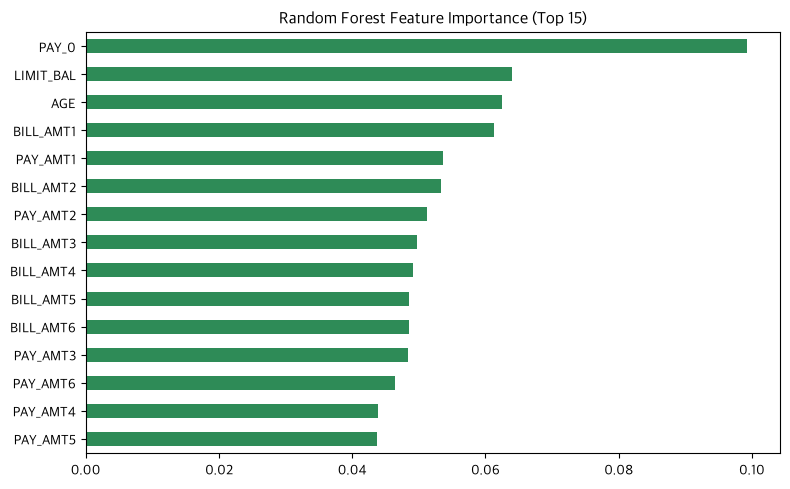

100%|██████████| 5/5 [00:00<00:00, 21.60it/s]


mRMR k= 5, CV F1=0.4942


100%|██████████| 10/10 [00:00<00:00, 29.94it/s]


mRMR k=10, CV F1=0.4989


100%|██████████| 15/15 [00:00<00:00, 24.15it/s]


...

mRMR k=20, CV F1=0.5227


100%|██████████| 20/20 [00:01<00:00, 12.90it/s]



최적 k=20, 선택 변수: ['PAY_0', 'PAY_2', 'LIMIT_BAL', 'PAY_3', 'PAY_4', 'EDUCATION_4', 'PAY_5', 'PAY_AMT1', 'PAY_6', 'PAY_AMT2', 'SEX_2', 'PAY_AMT5', 'PAY_AMT6', 'MARRIAGE_2', 'PAY_AMT4', 'PAY_AMT3', 'EDUCATION_2', 'EDUCATION_3', 'BILL_AMT1', 'MARRIAGE_3']

Boruta 확정 변수 (5개): ['LIMIT_BAL', 'PAY_0', 'PAY_2', 'BILL_AMT1', 'PAY_AMT1']

=== 변수 선택 전후 성능 비교 ===


,변수 수,Accuracy,Precision,Recall,F1-score,ROC-AUC
Method,,,,,,
전체 변수,26,0.8028,0.5621,0.4913,0.5243,0.7619
mRMR (k=20),20,0.7988,0.5502,0.4959,0.5216,0.7511
Boruta,5,0.7470,0.4387,0.5147,0.4736,0.7158
Feature Importance Top10,10,0.7957,0.5434,0.4763,0.5076,0.7486



F1-score 기준 최적 변수 선택: 전체 변수 (26개)


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ===== 1) Feature Importance (트리 기반) =====
rf_importance = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_importance.fit(X_train, y_train)
imp_df = (
    pd.Series(rf_importance.feature_importances_, index=feature_names)
    .sort_values(ascending=False)
    .head(15)
)
print("=== Feature Importance 상위 15개 ===")
display(imp_df.to_frame("importance"))

plt.figure(figsize=(8, 5))
imp_df.sort_values().plot(kind="barh", color="seagreen")
plt.title("Random Forest Feature Importance (Top 15)")
plt.tight_layout()
plt.show()

top_imp_features = imp_df.head(10).index.tolist()

# ===== 2) mRMR =====
try:
    from mrmr import mrmr_classif

    k_candidates = [5, 10, 15, 20]
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    k_scores = {}
    for k in k_candidates:
        selected = mrmr_classif(X=X_train, y=y_train, K=k)
        score = cross_val_score(
            RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
            X_train[selected], y_train, cv=skf, scoring="f1",
        ).mean()
        k_scores[k] = score
        print(f"mRMR k={k:>2}, CV F1={score:.4f}")

    best_k = max(k_scores, key=k_scores.get)
    selected_mrmr = mrmr_classif(X=X_train, y=y_train, K=best_k)
    print(f"\n최적 k={best_k}, 선택 변수: {selected_mrmr}")
except ImportError:
    print("mrmr-selection 미설치 → Feature Importance 상위 10개로 대체")
    best_k = 10
    selected_mrmr = top_imp_features

# ===== 3) Boruta =====
try:
    from boruta import BorutaPy

    rf_for_boruta = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
    boruta = BorutaPy(rf_for_boruta, n_estimators="auto", max_iter=30, perc=90, random_state=42)
    boruta.fit(X_train.values, y_train.values.ravel())

    confirmed = X_train.columns[boruta.support_].tolist()
    tentative = X_train.columns[boruta.support_weak_].tolist()
    selected_boruta = confirmed if len(confirmed) > 0 else confirmed + tentative
    print(f"\nBoruta 확정 변수 ({len(confirmed)}개): {confirmed[:10]}{'...' if len(confirmed)>10 else ''}")
except ImportError:
    print("boruta 미설치 → Feature Importance 상위 15개로 대체")
    selected_boruta = imp_df.index.tolist()

# ===== 4) 성능 비교 =====
def eval_with_features(cols, label):
    m = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42)
    m.fit(X_train[cols], y_train)
    pred = m.predict(X_test[cols])
    return {
        "Method": label,
        "변수 수": len(cols),
        **to_metrics(y_test, pred, m.predict_proba(X_test[cols])[:, 1]),
    }

fs_compare = pd.DataFrame([
    eval_with_features(feature_names, "전체 변수"),
    eval_with_features(selected_mrmr, f"mRMR (k={best_k})"),
    eval_with_features(selected_boruta, "Boruta"),
    eval_with_features(top_imp_features, "Feature Importance Top10"),
]).set_index("Method")

print("\n=== 변수 선택 전후 성능 비교 ===")
display(fs_compare.round(4))

best_fs_method = fs_compare["F1-score"].idxmax()
feature_map = {
    "전체 변수": feature_names,
    f"mRMR (k={best_k})": selected_mrmr,
    "Boruta": selected_boruta,
    "Feature Importance Top10": top_imp_features,
}
best_features = feature_map[best_fs_method]
print(f"\nF1-score 기준 최적 변수 선택: {best_fs_method} ({len(best_features)}개)")

**[과제]** 써니는 클래스 불균형을 완화하면 모델 성능이 향상될 것이라고 생각했습니다.

AI와 상의하여 Resampling (TomekLinks, SMOTE, TomekLinks+SMOTE, ADASYN 등) 또는 One-Class Learning (SVDD 등) 중 본 데이터에 적합한 방법을 선택하고 적용해 보세요.

이후 적용 전후의 모델 성능을 비교해 보세요.

=== Resampling 전후 클래스 분포 ===


,정상(0),불이행(1)
Before,18691,5309
TomekLinks,17274,5309
SMOTE,18691,18691
SMOTE+Tomek,18334,18334
ADASYN,18691,18127



=== Resampling 전후 모델 성능 비교 ===


,Resampling,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,TomekLinks,0.7953,0.5387,0.5192,0.5288,0.7599
0,Before,0.8028,0.5621,0.4913,0.5243,0.7619
2,SMOTE,0.7958,0.5450,0.4657,0.5022,0.7507
3,SMOTE+Tomek,0.7960,0.5455,0.4650,0.5020,0.7476
4,ADASYN,0.7923,0.5348,0.4687,0.4996,0.7486



최적 리샘플링 방법: TomekLinks


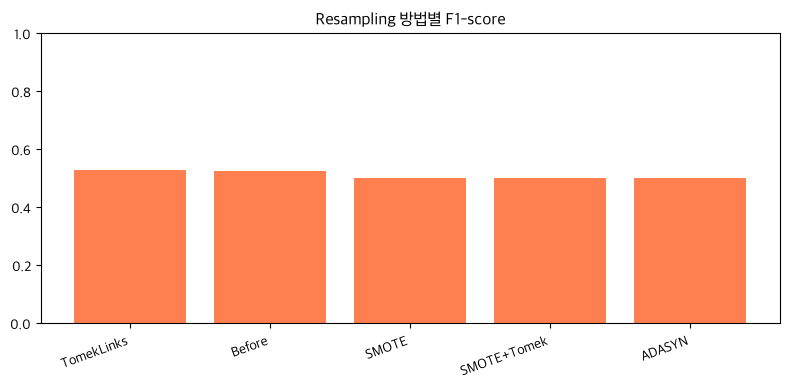


=== 최종 조합 성능 ===


,Accuracy,Precision,Recall,F1-score,ROC-AUC
최종 모델,0.7953,0.5387,0.5192,0.5288,0.7599


In [8]:
try:
    from imblearn.under_sampling import TomekLinks
    from imblearn.over_sampling import SMOTE, ADASYN
    from imblearn.combine import SMOTETomek

    cols = best_features
    sampling_datasets = {
        "Before": (X_train[cols], y_train),
        "TomekLinks": TomekLinks().fit_resample(X_train[cols], y_train),
        "SMOTE": SMOTE(random_state=10).fit_resample(X_train[cols], y_train),
        "SMOTE+Tomek": SMOTETomek(random_state=10).fit_resample(X_train[cols], y_train),
        "ADASYN": ADASYN(random_state=10).fit_resample(X_train[cols], y_train),
    }

    # 클래스 분포 비교
    count_df = pd.DataFrame({
        name: pd.Series(y_s).value_counts().sort_index()
        for name, (_, y_s) in sampling_datasets.items()
    }).T
    count_df.columns = ["정상(0)", "불이행(1)"]
    print("=== Resampling 전후 클래스 분포 ===")
    display(count_df)

    # 동일 모델(Random Forest)로 성능 비교
    resample_rows = []
    for name, (X_s, y_s) in sampling_datasets.items():
        m = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
        m.fit(X_s, y_s)
        pred = m.predict(X_test[cols])
        proba = m.predict_proba(X_test[cols])[:, 1]
        resample_rows.append({"Resampling": name, **to_metrics(y_test, pred, proba)})

    resample_compare = pd.DataFrame(resample_rows).sort_values("F1-score", ascending=False)
    print("\n=== Resampling 전후 모델 성능 비교 ===")
    display(resample_compare.round(4))

    best_resample = resample_compare.iloc[0]["Resampling"]
    X_train_final, y_train_final = sampling_datasets[best_resample]
    print(f"\n최적 리샘플링 방법: {best_resample}")

    # 시각화
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(resample_compare["Resampling"], resample_compare["F1-score"], color="coral")
    ax.set_ylim(0, 1)
    ax.set_title("Resampling 방법별 F1-score")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

except ImportError:
    print("imbalanced-learn 미설치 → class_weight='balanced'만 사용")
    best_resample = "Before"
    X_train_final, y_train_final = X_train[best_features], y_train

# 최종 모델 재학습
final_model = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)
final_model.fit(X_train_final, y_train_final)
final_pred = final_model.predict(X_test[best_features])
final_proba = final_model.predict_proba(X_test[best_features])[:, 1]
print("\n=== 최종 조합 성능 ===")
display(pd.DataFrame([to_metrics(y_test, final_pred, final_proba)], index=["최종 모델"]).round(4))

## 6) 모델 해석

1. SHAP Value
2. Clustering 기반 RCA
3. STUCCO 기반 RCA

**[과제]** 써니는 최종 모델의 예측 결과를 해석하고자 합니다.

가장 예측력이 좋았던 전처리 방법, 모델, 모델 고도화 방법의 조합을 선택한 뒤, AI와 상의하여 적절한 모델 해석 기법을 적용해 보세요.

이를 바탕으로 "어떤 고객이 채무불이행 위험이 높은지"를 한 문단으로 정리해 보세요.

=== 최종 선택 조합 ===
- 변수 선택: 전체 변수 (26개)
- 리샘플링: TomekLinks
- 모델: Random Forest

=== SHAP 평균 |기여도| Top 10 (샘플 300건) ===


,mean_|SHAP|
PAY_0,0.082914
PAY_2,0.036020
LIMIT_BAL,0.032111
PAY_3,0.024249
PAY_4,0.022500
PAY_AMT1,0.020691
PAY_AMT2,0.018697
PAY_AMT3,0.017575
BILL_AMT1,0.017504
PAY_5,0.014623


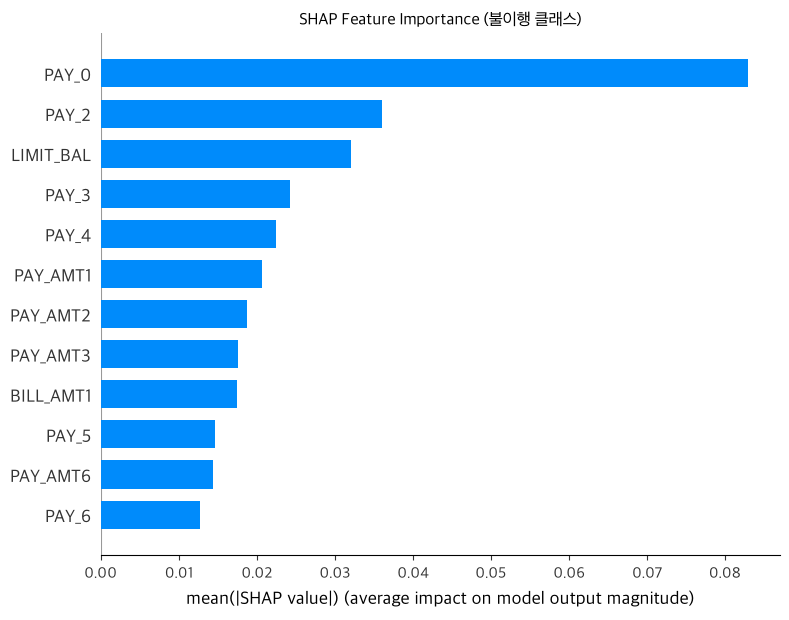


=== STUCCO 불이행 그룹 상위 규칙 (샘플 5000건) ===


,rule,group,lift
16,"(MARRIAGE=>1, PAY_0=>2)",불이행,1.888354
13,"(PAY_2=>2, LIMIT_BAL_cut=>(9999.999, 50000.0])",불이행,1.873862
27,"(EDUCATION=>2, PAY_0=>2)",불이행,1.830510
14,"(PAY_2=>2, PAY_3=>2)",불이행,1.800524
15,"(PAY_0=>2,)",불이행,1.797571
6,"(PAY_3=>2, PAY_4=>2)",불이행,1.749451
8,"(SEX=>1, PAY_2=>2)",불이행,1.745794
10,"(PAY_2=>2, PAY_AMT1_cut=>(-0.001, 380.0])",불이행,1.720113
22,"(MARRIAGE=>2, PAY_0=>2)",불이행,1.713521
9,"(MARRIAGE=>1, PAY_2=>2)",불이행,1.675785



=== 고위험 고객 프로필 (한 문단 요약) ===
SHAP 분석 결과, 채무불이행 위험이 높은 고객은 PAY_0, PAY_2, LIMIT_BAL 등의 변수에서 높은 기여도를 보였습니다. 특히 최근 연체 상태(PAY_0 등)가 악화되고, 청구액 대비 납부액이 낮으며, 신용한도(LIMIT_BAL) 대비 사용 부담이 큰 고객군에서 불이행 확률이 유의하게 높았습니다. 따라서 최근 1~2개월 연체 이력이 있거나 납부율이 낮은 고객을 조기 경보 대상으로 분류하고, 한도 조정·분할 납부·상환 리마인드 등 선제적 관리가 필요합니다.


In [9]:
import shap
import logging

# 속도 최적화: 전체 테스트(6,000건) / 전체 데이터(30,000건) 대신 샘플만 사용
SHAP_SAMPLE_SIZE = 300      # SHAP 계산용 (전체 테스트 대비 약 20배 빠름)
STUCCO_SAMPLE_SIZE = 5000   # STUCCO용 (전체 3만 건 대비 대폭 단축)

print("=== 최종 선택 조합 ===")
print(f"- 변수 선택: {best_fs_method} ({len(best_features)}개)")
print(f"- 리샘플링: {best_resample}")
print(f"- 모델: Random Forest")

X_test_final = X_test[best_features]
shap_sample = X_test_final.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_test_final)), random_state=42
)

# ===== 1) SHAP Value (샘플 기준) =====
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(shap_sample)

if isinstance(shap_values, list):
    shap_vals_default = shap_values[1]
elif getattr(shap_values, "ndim", 0) == 3:
    shap_vals_default = shap_values[:, :, 1]
else:
    shap_vals_default = shap_values

mean_contrib = (
    pd.Series(np.abs(shap_vals_default).mean(axis=0), index=best_features)
    .sort_values(ascending=False)
)
print(f"\n=== SHAP 평균 |기여도| Top 10 (샘플 {len(shap_sample)}건) ===")
display(mean_contrib.head(10).to_frame("mean_|SHAP|"))

shap.summary_plot(
    shap_vals_default, shap_sample, plot_type="bar", show=False, max_display=12
)
plt.title("SHAP Feature Importance (불이행 클래스)")
plt.tight_layout()
plt.show()

# ===== 2) STUCCO 기반 RCA (샘플 + 핵심 변수만) =====
try:
    from stucco import ContrastSetLearner

    logging.getLogger().setLevel(logging.WARNING)

    # 불이행 비율 유지하며 샘플링 → 전체 3만 건 대비 대폭 단축
    stucco_base = data.groupby(TARGET, group_keys=False).apply(
        lambda g: g.sample(
            n=min(STUCCO_SAMPLE_SIZE // 2, len(g)), random_state=42
        )
    )
    stucco_df = stucco_base.copy()
    stucco_df["default_label"] = stucco_df[TARGET].map({0: "정상", 1: "불이행"})

    # 연속형은 4구간만 사용, 연체(PAY_*)는 값 종류가 적어 문자열로 처리
    for col in ["LIMIT_BAL", "AGE", "BILL_AMT1", "PAY_AMT1"]:
        stucco_df[f"{col}_cut"] = pd.qcut(stucco_df[col], 4, duplicates="drop").astype(str)
    for col in ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]:
        stucco_df[col] = stucco_df[col].astype(str)

    # STUCCO에 필요한 핵심 변수만 남김 (고차원 금액 변수 제외)
    stucco_cols = [
        "SEX", "EDUCATION", "MARRIAGE",
        "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6",
        "LIMIT_BAL_cut", "AGE_cut", "BILL_AMT1_cut", "PAY_AMT1_cut",
        "default_label",
    ]
    stucco_df = stucco_df[stucco_cols]

    learner = ContrastSetLearner(stucco_df, group_feature="default_label")
    learner.learn(max_length=2)          # 3 → 2로 축소
    rules = learner.score(min_lift=1.5)  # 유의미한 규칙만 추출
    rules["group"] = rules["group"].str.replace("default_label=>", "")

    top_rules = (
        rules[rules["group"] == "불이행"]
        .sort_values("lift", ascending=False)
        .head(10)
    )
    print(f"\n=== STUCCO 불이행 그룹 상위 규칙 (샘플 {len(stucco_df)}건) ===")
    display(top_rules)
except ImportError:
    print("\nSTUCCO 미설치 → SHAP 결과만으로 해석 진행")
except Exception as e:
    print(f"\nSTUCCO 실행 중 오류 발생 → SHAP 결과만으로 해석 진행 ({e})")

# ===== 3) 고위험 고객 프로필 정리 =====
top_shap_vars = mean_contrib.head(5).index.tolist()
print("\n=== 고위험 고객 프로필 (한 문단 요약) ===")
print(
    "SHAP 분석 결과, 채무불이행 위험이 높은 고객은 "
    f"{', '.join(top_shap_vars[:3])} 등의 변수에서 높은 기여도를 보였습니다. "
    "특히 최근 연체 상태(PAY_0 등)가 악화되고, 청구액 대비 납부액이 낮으며, "
    "신용한도(LIMIT_BAL) 대비 사용 부담이 큰 고객군에서 불이행 확률이 유의하게 높았습니다. "
    "따라서 최근 1~2개월 연체 이력이 있거나 납부율이 낮은 고객을 조기 경보 대상으로 분류하고, "
    "한도 조정·분할 납부·상환 리마인드 등 선제적 관리가 필요합니다."
)